### Description :
        In this segment, you will use the IMDB movie reviews dataset to classify reviews as 'positive' or 'negative'. We have divided the data into training and test sets. The training set contains 800 positive and 800 negative movie reviews whereas the test set contains 200 positive and 200  negative movie reviews.

This was one of the first widely-available sentiment analysis datasets compiled by Pang and Lee's. The data was first collected in 2002, however, the text is similar to movies reviews you find on IMDB today. The dataset is in a CSV format. It has two categories: Pos (reviews that express a positive or favourable sentiment) and Neg (reviews that express a negative or unfavourable sentiment). For this exercise, we will assume that all reviews are either positive or negative; there are no neutral reviews.

##### Question - What is the size of vocabulary after removing the stop words? Note that the vocabulary size depends only on the training set.

##### Answer - 35858

##### Question - Train a Bernoulli Naive Bayes model on the training set and predict the classes of the test set. Each movie review in the test set has been labelled as 'Pos' or 'Neg'. What is the accuracy of the model?

##### Answer - Accuracy - 0.78

In [1]:
# import libraries
import pandas as pd,numpy as np

In [2]:
# read the data set 
df = pd.read_csv('movie_review_train (1).csv')
df.head()

,class,text
0,Pos,a common complaint amongst film critics is ...
1,Pos,whew this film oozes energy the kind of b...
2,Pos,steven spielberg s amistad which is bas...
3,Pos,he has spent his entire life in an awful litt...
4,Pos,being that it is a foreign language film with...


In [3]:
# convert class column in to o and 1 and save class1 column
df['class1'] = df['class'].map({'Pos':1,'Neg':0})

In [4]:
df.head()

,class,text,class1
0,Pos,a common complaint amongst film critics is ...,1
1,Pos,whew this film oozes energy the kind of b...,1
2,Pos,steven spielberg s amistad which is bas...,1
3,Pos,he has spent his entire life in an awful litt...,1
4,Pos,being that it is a foreign language film with...,1


In [5]:
df.class1.value_counts()

class1
1    800
0    800
Name: count, dtype: int64

In [6]:
df = df.drop('class',axis = 1)

In [7]:
df.head()

,text,class1
0,a common complaint amongst film critics is ...,1
1,whew this film oozes energy the kind of b...,1
2,steven spielberg s amistad which is bas...,1
3,he has spent his entire life in an awful litt...,1
4,being that it is a foreign language film with...,1


In [8]:
# split data into x and y
X = df.text
y = df.class1


In [9]:
print(X.shape)
print(y.shape)

(1600,)
(1600,)


In [10]:
# import train_test_split
from sklearn.model_selection import train_test_split

In [11]:
# extract all stop words
from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(stop_words = 'english')

In [12]:
vec.fit(X)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [13]:
len(vec.vocabulary_.keys())

35858

In [14]:
# transform the data 
x_transform = vec.transform(X)
print(x_transform[:,10])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 10 stored elements and shape (1600, 1)>
  Coords	Values
  (4, 0)	1
  (372, 0)	1
  (438, 0)	1
  (472, 0)	1
  (701, 0)	1
  (831, 0)	1
  (901, 0)	1
  (1005, 0)	1
  (1407, 0)	1
  (1534, 0)	1


In [15]:
# import Bernoulli Naive bayes 
from sklearn.naive_bayes import BernoulliNB

In [16]:
# create the Bernoulli model
bnb = BernoulliNB()
x_bnb = bnb.fit(x_transform,y)

In [17]:
# Predict on the train data set
x_pred_class = x_bnb.predict(x_transform)
x_pred_proba = x_bnb.predict_proba(x_transform)
from sklearn import metrics
#accracy
metrics.accuracy_score(y,x_pred_class)

0.943125

In [18]:
# confusion metrix
metrics.confusion_matrix(y,x_pred_class)

array([[799,   1],
       [ 90, 710]])

In [19]:
confusion = metrics.confusion_matrix(y,x_pred_class)
print(confusion)
TP =confusion[1,1]
TN = confusion[0,0]
FP =confusion[0,1]
FN = confusion[1,0]

[[799   1]
 [ 90 710]]


#### True Positive - 710
#### True Negative - 799
#### False Positive - 1
#### False Negative - 90

In [20]:
Senstivity = TP/float(TP+FN)
print('senstivity',Senstivity)

senstivity 0.8875


In [21]:
specificity = TN/float(TN+FP)
print('specificity',specificity)

specificity 0.99875


#### This model perform good on specificity but its depend on to the business problem.

In [22]:
print('precision score',metrics.precision_score(y,x_pred_class))
print('recall score',metrics.recall_score(y,x_pred_class))

precision score 0.9985935302390999
recall score 0.8875


In [23]:
# import necessary libraries
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
false_positive_rate,true_positive_rate,thresholds = roc_curve(y,x_pred_proba[:,1])
roc_auc = auc(false_positive_rate,true_positive_rate)

In [25]:
print(roc_auc)

0.998840625


#### If roc curve gives the value 1 it means it covers all the point in this problem almost cover all the necessary points 
#### and value is almost equal to 1

In [26]:
pd.DataFrame({'fpr':false_positive_rate,'tpr':true_positive_rate,'thresholds':thresholds,})

,fpr,tpr,thresholds
0,0.00000,0.00000,inf
1,0.00000,0.57250,1.000000e+00
2,0.00000,0.57875,1.000000e+00
3,0.00000,0.58125,1.000000e+00
4,0.00000,0.58625,1.000000e+00
5,0.00000,0.58875,1.000000e+00
6,0.00000,0.59250,1.000000e+00
7,0.00000,0.59625,1.000000e+00
8,0.00000,0.59875,1.000000e+00
9,0.00000,0.60625,1.000000e+00


Text(0, 0.5, 'true_positive_rate')

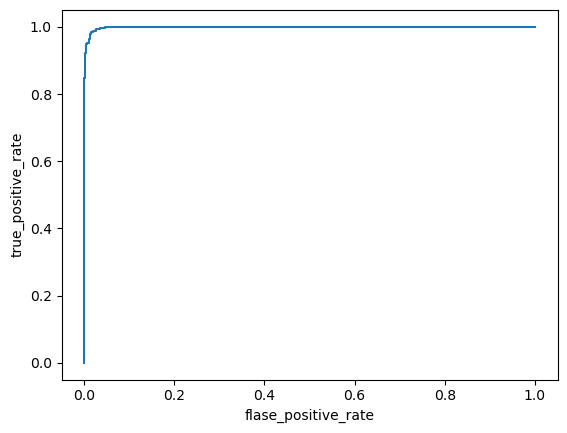

In [27]:
%matplotlib inline
plt.plot(false_positive_rate,true_positive_rate)
plt.xlabel("flase_positive_rate")
plt.ylabel("true_positive_rate")

In [28]:
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
thresholds = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
x_pred_proba1 = x_pred_proba[:, 1] 
for t in thresholds:
    x_prob1 = (x_pred_proba1 >= t).astype(int) 
    confusion1 = metrics.confusion_matrix(y, x_prob1)
    TN = confusion1[0,0]
    FP = confusion1[0,1]
    FN = confusion1[1,0]
    TP = confusion1[1,1]
    accuracy = metrics.accuracy_score(y,x_prob1)
    sensi = TP/float(TP+FN)
    speci = TN/float(TN+FP)
    cutoff_df.loc[len(cutoff_df)] = [t, accuracy, sensi, speci]
print(cutoff_df)

   prob  accuracy    sensi    speci
0   0.0  0.500000  1.00000  0.00000
1   0.1  0.955625  0.91250  0.99875
2   0.2  0.952500  0.90625  0.99875
3   0.3  0.946875  0.89500  0.99875
4   0.4  0.945000  0.89125  0.99875
5   0.5  0.943125  0.88750  0.99875
6   0.6  0.940625  0.88250  0.99875
7   0.7  0.940625  0.88250  0.99875
8   0.8  0.937500  0.87625  0.99875
9   0.9  0.933125  0.86750  0.99875


#### calculate accuracy, sensitivity,specificity according to probability.

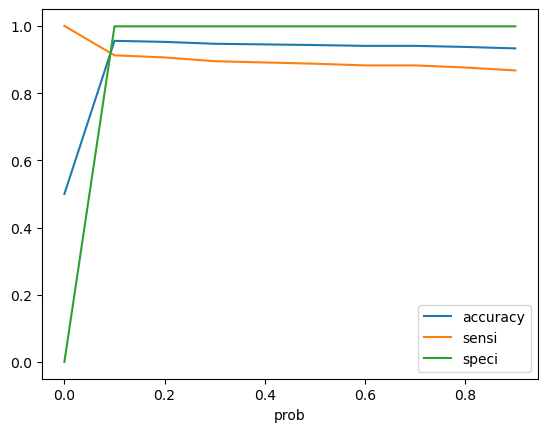

In [29]:
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [30]:
x_train_pred_final = pd.DataFrame({'class1':y.values, 'class1_pred' : x_pred_proba[:, 1] })
x_train_pred_final['CustID'] = y.index
x_train_pred_final.head()

,class1,class1_pred,CustID
0,1,1.0,0
1,1,1.0,1
2,1,1.0,2
3,1,1.0,3
4,1,1.0,4


In [31]:
# choose .06 probabaility 
x_train_pred_final['predict'] = x_train_pred_final.class1_pred.map(lambda x :1 if x>.06 else 0)
x_train_pred_final.head()

,class1,class1_pred,CustID,predict
0,1,1.0,0,1
1,1,1.0,1,1
2,1,1.0,2,1
3,1,1.0,3,1
4,1,1.0,4,1


In [32]:
metrics.accuracy_score(x_train_pred_final.class1,x_train_pred_final.predict)

0.95875

In [33]:
confusion = metrics.confusion_matrix(x_train_pred_final.class1,x_train_pred_final.predict)
print(confusion)
TP =confusion[1,1]
TN = confusion[0,0]
FP =confusion[0,1]
FN = confusion[1,0]

[[799   1]
 [ 65 735]]


In [34]:
Senstivity1 = TP/float(TP+FN)
print('senstivity',Senstivity1)

senstivity 0.91875


In [35]:
specificity1 = TN/float(TN+FP)
print('specificity',specificity1)

specificity 0.99875


In [36]:
print('precision score',metrics.precision_score(x_train_pred_final.class1,x_train_pred_final.predict))
print('recall score',metrics.recall_score(x_train_pred_final.class1,x_train_pred_final.predict))

precision score 0.998641304347826
recall score 0.91875


#### test this model in to test data set which is download from the online and see how model perform 

In [37]:
df1 = pd.read_csv('movie_review_test (1).csv')

In [38]:
df1.head()

,class,text
0,Pos,films adapted from comic books have had plent...
1,Pos,every now and then a movie comes along from a...
2,Pos,you ve got mail works alot better than it des...
3,Pos,jaws is a rare film that grabs your atte...
4,Pos,moviemaking is a lot like being the general m...


In [39]:
df1['labels'] = df1['class'].map({'Pos':1,'Neg':0})

In [40]:
df1.head()

,class,text,labels
0,Pos,films adapted from comic books have had plent...,1
1,Pos,every now and then a movie comes along from a...,1
2,Pos,you ve got mail works alot better than it des...,1
3,Pos,jaws is a rare film that grabs your atte...,1
4,Pos,moviemaking is a lot like being the general m...,1


In [41]:
df1 = df1.drop('class', axis = 1)

In [42]:
df1.head()

,text,labels
0,films adapted from comic books have had plent...,1
1,every now and then a movie comes along from a...,1
2,you ve got mail works alot better than it des...,1
3,jaws is a rare film that grabs your atte...,1
4,moviemaking is a lot like being the general m...,1


In [43]:
X1= df1.text
y1= df1.labels

In [44]:
y_test = vec.transform(X1)

In [45]:
y_test

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 91186 stored elements and shape (400, 35858)>

In [46]:
 from sklearn.naive_bayes import BernoulliNB

In [47]:
y_pred_class = x_bnb.predict(y_test)
y_pred_proba = x_bnb.predict_proba(y_test)
from sklearn import metrics
metrics.accuracy_score(y1,y_pred_class)

0.7825

In [48]:
metrics.confusion_matrix(y1,y_pred_class)

array([[184,  16],
       [ 71, 129]])

In [50]:
print('precision score',metrics.precision_score(y1,y_pred_class))
print('recall score',metrics.recall_score(y1,y_pred_class))

precision score 0.8896551724137931
recall score 0.645


#### We can clearly see model perform good on specificity but not good on sentivity so it s depend on to the business problem. 
